# 3 — Inverse Kinematics

Put the foot *there* · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/03-inverse-kinematics/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## Reversing last week

Last week: **angles in, foot position out.** One answer, always,
computed in twelve lines.

This week: **foot position in, angles out.** And now the question
misbehaves.

- there may be **no** solution — the target is out of reach
- there may be **many** — knee forward or knee back
- there may be **infinitely many** — more joints than constraints
- near some poses the answer exists but **explodes**

Every one of those is a real situation the Week 4 walker has to survive.

------------------------------------------------------------------------

## Nothing is falling today

Inverse kinematics is a statement about **geometry**, not balance. A
pose that solves perfectly may be one the robot cannot hold for a
moment.

So today we render **kinematics only** — poses placed and drawn, physics
never stepped. Nothing falls over, because nothing is being simulated.

Keeping that separation clear now is what lets Week 4 combine them
deliberately.

------------------------------------------------------------------------

## The easy case: two links in a plane

Ignore the hip’s roll and yaw and the ankle. What is left is a thigh and
a shin — two links, one plane. The law of cosines solves it outright.

With thigh $\ell_1$, shin $\ell_2$, and a target a distance $d$ from the
hip:

$$\cos\theta_{\text{knee}} = \frac{d^2 - \ell_1^2 - \ell_2^2}{2\,\ell_1\ell_2}$$

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import mujoco
from soc4180 import kinematics as kin

model = soc4180.load_g1()
data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)

def anchor(body_name):
    """World position of a body's joint axis — where the link actually pivots."""
    b = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body_name)
    j = model.body_jntadr[b]
    return data.xpos[b] + data.xmat[b].reshape(3, 3) @ model.jnt_pos[j]

thigh = np.linalg.norm(anchor("left_knee_link") - anchor("left_hip_pitch_link"))
shin = np.linalg.norm(anchor("left_ankle_pitch_link") - anchor("left_knee_link"))
print(f"thigh  l1 = {thigh:.4f} m")
print(f"shin   l2 = {shin:.4f} m")
print(f"reach is an annulus: {abs(thigh-shin):.4f} m to {thigh+shin:.4f} m")

thigh  l1 = 0.3409 m
shin   l2 = 0.3000 m
reach is an annulus: 0.0409 m to 0.6409 m

------------------------------------------------------------------------

## What the closed form tells you

In [2]:
def knee_angle(d, l1=thigh, l2=shin):
    """Interior knee angle for a hip-to-foot distance d, or None if unreachable."""
    c = (d**2 - l1**2 - l2**2) / (2 * l1 * l2)
    if abs(c) > 1.0:
        return None                      # outside the annulus: no solution
    return np.arccos(c)

for dist in (0.02, 0.20, 0.40, 0.60, 0.64, 0.70):
    a = knee_angle(dist)
    print(f"  d={dist:.2f} m -> " +
          ("unreachable" if a is None else f"knee bend {np.degrees(np.pi - a):6.1f} deg"))

  d=0.02 m -> unreachable
  d=0.20 m -> knee bend   35.6 deg
  d=0.40 m -> knee bend   76.9 deg
  d=0.60 m -> knee bend  138.7 deg
  d=0.64 m -> knee bend  173.8 deg
  d=0.70 m -> unreachable

Three lessons in one table:

- Reachable distances form an **annulus**, not a disc — too close is as
  impossible as too far
- $\arccos$ returns one angle, but $-\theta$ works equally well: **two
  solutions**, knee-forward and knee-back. Humans use one of them; the
  mathematics does not care
- As $d$ approaches $\ell_1+\ell_2$ the knee straightens, and the
  sensitivity of angle to distance **diverges**

------------------------------------------------------------------------

## Seen, not read

Differentiate the law of cosines and the sensitivity of angle to
distance falls out with $\sin\theta$ in the denominator:

$$\left|\frac{d\theta}{d\,d}\right| = \frac{d}{\ell_1\,\ell_2\,\sin\theta}$$

At full reach $\theta \to \pi$, $\sin\theta \to 0$, and one millimetre
of target asks for whole degrees of knee.

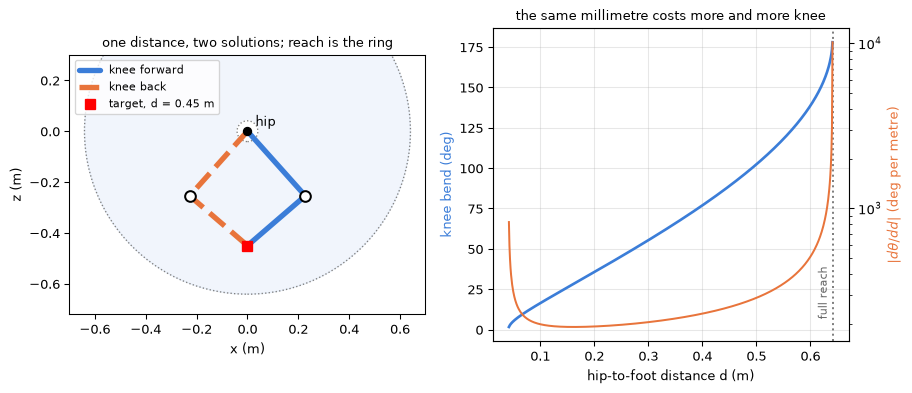

In [3]:
import matplotlib.pyplot as plt

d = np.linspace(abs(thigh - shin) + 1e-3, thigh + shin - 1e-4, 600)
c = (d**2 - thigh**2 - shin**2) / (2 * thigh * shin)
bend = np.pi - np.arccos(c)                       # bend = 0 is a straight leg
sens = d / (thigh * shin * np.sqrt(1 - c**2))     # |d theta / d d|

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 4.2))

# left: one target distance, both solutions, drawn inside the reachable ring
d_show = 0.45
phi = np.arccos((thigh**2 + d_show**2 - shin**2) / (2 * thigh * d_show))   # hip angle
ax0.add_patch(plt.Circle((0, 0), thigh + shin, color="#3b7dd8", alpha=0.07, zorder=0))
ax0.add_patch(plt.Circle((0, 0), abs(thigh - shin), color="w", zorder=1))
for r in (thigh + shin, abs(thigh - shin)):
    ax0.add_patch(plt.Circle((0, 0), r, fill=False, ls=":", color="0.5", zorder=1))
for sgn, style, col, label in ((+1, "-", "#3b7dd8", "knee forward"),
                               (-1, "--", "#e8743b", "knee back")):
    kx, kz = sgn * thigh * np.sin(phi), -thigh * np.cos(phi)
    ax0.plot([0, kx, 0], [0, kz, -d_show], style, lw=4, color=col,
             solid_capstyle="round", label=label, zorder=3)
    ax0.plot(kx, kz, "o", ms=8, color="w", mec="k", mew=1.5, zorder=4)
ax0.plot(0, 0, "ko", ms=6, zorder=4)
ax0.plot(0, -d_show, "rs", ms=8, label=f"target, d = {d_show} m", zorder=4)
ax0.annotate("hip", (0, 0), xytext=(6, 4), textcoords="offset points")
ax0.set_aspect("equal"); ax0.set_xlim(-0.7, 0.7); ax0.set_ylim(-0.72, 0.3)
ax0.set_xlabel("x (m)"); ax0.set_ylabel("z (m)")
ax0.legend(fontsize=8, loc="upper left")
ax0.set_title("one distance, two solutions; reach is the ring", fontsize=10)

# right: knee bend and its sensitivity against distance
ax1.plot(d, np.degrees(bend), lw=2, color="#3b7dd8")
ax1.set_xlabel("hip-to-foot distance d (m)")
ax1.set_ylabel("knee bend (deg)", color="#3b7dd8")
ax1.axvline(thigh + shin, color="0.5", ls=":")
ax1.text(thigh + shin - 0.006, 8, "full reach", rotation=90, fontsize=8, color="0.4", ha="right")
ax2 = ax1.twinx()
ax2.semilogy(d, np.degrees(sens), lw=1.5, color="#e8743b")
ax2.set_ylabel(r"$|d\theta/dd|$ (deg per metre)", color="#e8743b")
ax1.set_title("the same millimetre costs more and more knee", fontsize=10)
ax1.grid(alpha=0.3)
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Why we cannot stop there

The closed form handles two joints in a plane. A real foot pose is **six
numbers** — three position, three orientation — and the leg has six
joints.

Deriving closed-form IK for all six is possible, and it is:

- specific to this exact robot, and wrong for any other
- painful to extend when a joint limit or an obstacle intrudes
- brittle: a small model change invalidates the derivation

So we use a method that needs no derivation at all, works for any chain,
and degrades gracefully when the problem is ill-posed.

------------------------------------------------------------------------

## Differential IK

Do not solve for the angles. Solve for a **change** in the angles that
reduces the error, then repeat.

From last week, $\dot{\mathbf{x}} = J(q)\,\dot{q}$. Ask for the joint
change that produces a desired foot motion $\mathbf{e}$:

$$J\,\Delta q = \mathbf{e}$$

For our square $6\times6$ Jacobian you might just invert it. **Do not.**
Near a singularity $J$ is nearly rank-deficient, $J^{-1}$ becomes
enormous, and the solver commands joint velocities no motor could
produce.

------------------------------------------------------------------------

## Damped least squares

Instead of demanding an exact solution, ask for a compromise: reduce the
error *and* keep the joint motion small.

$$\Delta q = J^{\mathsf{T}}\left(J J^{\mathsf{T}} + \lambda^2 I\right)^{-1}\mathbf{e}$$

$\lambda$ trades accuracy against stability. Away from singularities it
barely matters; near one it is the difference between a smooth motion
and a violent lunge.

In [4]:
jac_p, jac_r = np.zeros((3, model.nv)), np.zeros((3, model.nv))
mujoco.mj_jacSite(model, data, jac_p, jac_r, kin.foot_site_id(model, "left"))
J = np.vstack([jac_p, jac_r])[:, kin.leg_dof_indices(model, "left")]

err = np.array([0.0, 0.0, -0.05, 0, 0, 0])       # ask to lower the foot 5 cm
for lam in (0.0, 1e-3, 1e-2, 1e-1):
    M = J @ J.T + lam**2 * np.eye(6)
    dq = J.T @ np.linalg.solve(M, err)
    print(f"  lambda={lam:<6}  |dq| = {np.linalg.norm(dq):10.2f} rad")

  lambda=0.0     |dq| =   55778.24 rad
  lambda=0.001   |dq| =       0.04 rad
  lambda=0.01    |dq| =       0.00 rad
  lambda=0.1     |dq| =       0.00 rad

------------------------------------------------------------------------

## Where the formula comes from

Ask for the $\Delta q$ that minimises

$$\|J\,\Delta q - \mathbf{e}\|^2 \;+\; \lambda^2\,\|\Delta q\|^2 .$$

The first term wants the error gone; the second charges for joint
motion. Setting the gradient to zero gives
$(J^{\mathsf T}J + \lambda^2 I)\,\Delta q =
J^{\mathsf T}\mathbf{e}$, which rearranges into the update on the
previous slide.

Write $J = U\,\Sigma\,V^{\mathsf T}$ and the update scales each singular
direction by

$$\frac{\sigma_i}{\sigma_i^2 + \lambda^2} \;\approx\;
\begin{cases} 1/\sigma_i & \sigma_i \gg \lambda \quad\text{the true inverse}\\[2pt]
\sigma_i/\lambda^2 \to 0 & \sigma_i \ll \lambda \quad\text{switched off}\end{cases}$$

$\lambda$ is a **threshold**: directions the Jacobian barely moves are
ignored rather than amplified. That is the whole trick.

------------------------------------------------------------------------

## The same sweep, from both poses

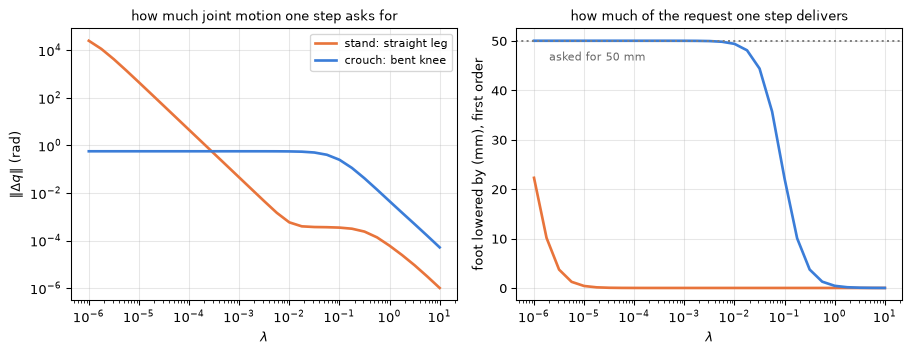

In [5]:
crouch = soc4180.WalkingController(model).nominal        # the week 4 crouch
bent = mujoco.MjData(model); bent.qpos[:] = crouch; mujoco.mj_forward(model, bent)
mujoco.mj_jacSite(model, bent, jac_p, jac_r, kin.foot_site_id(model, "left"))
J_crouch = np.vstack([jac_p, jac_r])[:, kin.leg_dof_indices(model, "left")]

lams = np.logspace(-6, 1, 29)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.8))
for Jp, label, col in ((J, "stand: straight leg", "#e8743b"),
                       (J_crouch, "crouch: bent knee", "#3b7dd8")):
    size, drop = [], []
    for lam in lams:
        dq = Jp.T @ np.linalg.solve(Jp @ Jp.T + lam**2 * np.eye(6), err)
        size.append(np.linalg.norm(dq)); drop.append(-(Jp @ dq)[2] * 1000)
    ax0.loglog(lams, size, lw=2, color=col, label=label)
    ax1.semilogx(lams, drop, lw=2, color=col, label=label)
ax0.set_xlabel(r"$\lambda$"); ax0.set_ylabel(r"$\|\Delta q\|$ (rad)"); ax0.legend(fontsize=8)
ax0.set_title("how much joint motion one step asks for", fontsize=10)
ax1.axhline(50, color="0.5", ls=":"); ax1.text(2e-6, 46, "asked for 50 mm", fontsize=8, color="0.4")
ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel("foot lowered by (mm), first order")
ax1.set_title("how much of the request one step delivers", fontsize=10)
for a in (ax0, ax1):
    a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Read the orange line left to right. Undamped, the straight leg asks for
tens of thousands of radians and lowers the foot 22 mm of the 50
requested; by $\lambda = 10^{-4}$ it asks for a sensible 4 rad and
delivers **nothing** — there is no direction to deliver it in. The blue
line delivers the full 50 mm for any $\lambda$ up to $10^{-3}$ and only
fades past $10^{-2}$. That fade is the trade: at $\lambda = 1$ the
crouched leg moves 0.4 mm per step.

------------------------------------------------------------------------

## That table is a singularity

Those numbers are not a quirk of the example. The `stand` keyframe has
**every leg joint at exactly zero** — a perfectly straight leg.

In [6]:
print("stand pose:", np.round(data.qpos[kin.leg_qpos_indices(model, "left")], 4))
sv = np.linalg.svd(J, compute_uv=False)
print(f"singular values      : {np.round(sv, 5)}")
print(f"smallest             : {sv[-1]:.2e}   <- effectively zero")
print(f"condition number     : {sv[0]/sv[-1]:.3e}")

stand pose: [0. 0. 0. 0. 0. 0.]
singular values      : [1.82956 1.48883 1.00031 0.42639 0.42172 0.     ]
smallest             : 8.96e-07   <- effectively zero
condition number     : 2.041e+06

A straight leg has **no direction that shortens it**. The Jacobian has
lost a rank, undamped IK divides by nearly zero, and no amount of
iteration helps — the information simply is not there.

------------------------------------------------------------------------

## Six singular values, two poses

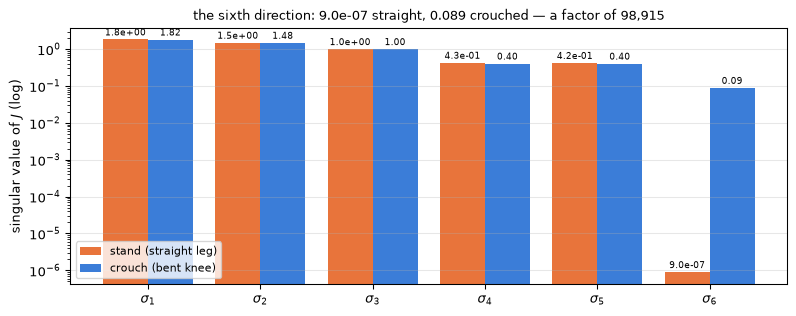

In [7]:
sv_crouch = np.linalg.svd(J_crouch, compute_uv=False)
fig, ax = plt.subplots(figsize=(8.4, 3.4))
x = np.arange(6)
ax.bar(x - 0.2, sv, 0.4, color="#e8743b", label="stand (straight leg)")
ax.bar(x + 0.2, sv_crouch, 0.4, color="#3b7dd8", label="crouch (bent knee)")
ax.set_yscale("log"); ax.set_xticks(x, [f"$\\sigma_{i + 1}$" for i in x])
ax.set_ylabel("singular value of $J$ (log)"); ax.legend(fontsize=8, loc="lower left")
for xi, (a, b) in enumerate(zip(sv, sv_crouch)):
    ax.annotate(f"{a:.1e}", (xi - 0.2, a), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=7)
    ax.annotate(f"{b:.2f}", (xi + 0.2, b), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=7)
ax.set_title(f"the sixth direction: {sv[-1]:.1e} straight, {sv_crouch[-1]:.3f} crouched "
             f"— a factor of {sv_crouch[-1] / sv[-1]:,.0f}", fontsize=10)
ax.grid(axis="y", alpha=0.3); fig.tight_layout(); plt.show()

Five of the six singular values barely change between the poses. The
sixth is the direction that *shortens the leg*, and bending the knee
restores it by a factor of about a hundred thousand. That one number is
why every gait in the course starts from a crouch.

------------------------------------------------------------------------

## The consequence, measured

Ask the solver to lower the pelvis 8 cm, from each of two seeds:

In [8]:
scratch = mujoco.MjData(model)
sid = {s: kin.foot_site_id(model, s) for s in ("left", "right")}
feet = {s: (data.site_xpos[sid[s]].copy(), data.site_xmat[sid[s]].reshape(3, 3).copy())
        for s in ("left", "right")}
base = data.qpos[:3].copy() - [0, 0, 0.08]

straight = data.qpos.copy()                       # the 'stand' singularity
crouch = soc4180.WalkingController(model).nominal  # bent knees

for label, seed in (("straight-leg seed", straight), ("crouched seed", crouch)):
    r = kin.ik_legs(model, scratch, base, data.qpos[3:7], feet,
                    seed_qpos=seed, iterations=40)
    print(f"  {label:20s} residual error = {r['error']:.2e}   knee = {r['left'][3]:+.3f} rad")

  straight-leg seed    residual error = 7.89e-01   knee = -0.087 rad
  crouched seed        residual error = 2.23e-06   knee = +1.015 rad

**The same request, the same solver, a different starting pose — and one
of them simply cannot be solved.** This is why every gait in this course
starts from a crouch, and why humans do not walk with locked knees.

------------------------------------------------------------------------

## Reaching a target

With the crouch as a seed, IK is exact. Move the foot somewhere new:

In [9]:
target = feet["left"][0] + np.array([0.15, 0.0, 0.05])
r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                {**feet, "left": (target, feet["left"][1])}, seed_qpos=crouch)

q = crouch.copy()
q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
for s in ("left", "right"):
    q[kin.leg_qpos_indices(model, s)] = r[s]
achieved, _ = soc4180.fk_foot(model, q, "left")

print(f"requested : {np.round(target, 5)}")
print(f"achieved  : {np.round(achieved, 5)}")
print(f"error     : {np.linalg.norm(achieved - target):.2e} m")
print(f"joint angles: {np.round(r['left'], 3)}")

requested : [0.15    0.11851 0.08314]
achieved  : [0.15    0.11851 0.08314]
error     : 1.29e-16 m
joint angles: [-0.546  0.    -0.     0.629 -0.083  0.   ]

Checked with **last week’s** forward kinematics, not with the solver’s
own opinion of itself.

------------------------------------------------------------------------

## Trace a circle

The real test of a solver is a whole path, not one point. Kinematics
only — the robot is placed, never simulated:

In [10]:
poses = []
centre = feet["left"][0] + np.array([0.05, 0.0, 0.06])
errors = []
seed = crouch.copy()

for angle in np.linspace(0, 2 * np.pi, 90):
    goal = centre + np.array([0.09 * np.cos(angle), 0.0, 0.04 * np.sin(angle)])
    r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                    {**feet, "left": (goal, feet["left"][1])}, seed_qpos=seed)
    q = seed.copy(); q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
    for s in ("left", "right"):
        q[kin.leg_qpos_indices(model, s)] = r[s]
    seed = q                      # warm start from the previous solution
    poses.append(q.copy()); errors.append(r["error"])

print(f"90 targets, worst residual error = {max(errors):.2e} m")
frames = soc4180.render_poses(model, poses, width=560, height=460)
soc4180.show_video(frames, fps=30)

90 targets, worst residual error = 8.37e-05 m

------------------------------------------------------------------------

## Ask for one centimetre more

Stretch the circle vertically and the solver stops tracking — but only
in one place:

In [11]:
worst, where = 0.0, None
seed = crouch.copy()
for angle in np.linspace(0, 2 * np.pi, 90):
    goal = centre + np.array([0.09 * np.cos(angle), 0.0, 0.06 * np.sin(angle)])
    r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                    {**feet, "left": (goal, feet["left"][1])},
                    seed_qpos=seed, iterations=120)
    q = seed.copy(); q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
    for side in ("left", "right"):
        q[kin.leg_qpos_indices(model, side)] = r[side]
    seed = q
    if r["error"] > worst:
        worst, where = r["error"], np.degrees(angle)

print(f"worst residual {worst:.2e} m, at {where:.0f} degrees around the circle")

worst residual 2.68e-03 m, at 279 degrees around the circle

**120 iterations changes nothing** — the error is identical at 12. That
is the signature of a target that is *unreachable*, not one the solver
ran out of time on. At the bottom of the circle the foot is asked to go
below what the leg can reach with the pelvis where it is: the annulus
from the start of the lecture, met from the outside.

A residual that will not shrink with more iterations is a **geometry**
problem. Only a residual that shrinks slowly is a solver problem.

------------------------------------------------------------------------

## Why exactly there

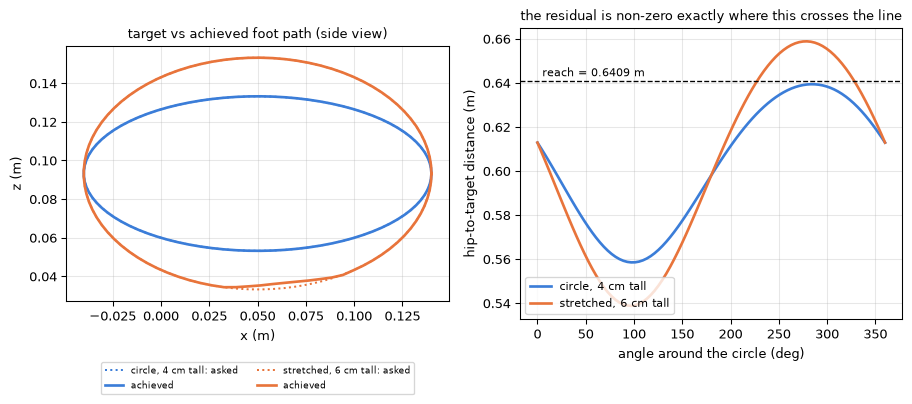

In [12]:
hip = anchor("left_hip_pitch_link")
angles = np.linspace(0, 2 * np.pi, 90)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 4.0))
for rz, col, label in ((0.04, "#3b7dd8", "circle, 4 cm tall"),
                       (0.06, "#e8743b", "stretched, 6 cm tall")):
    seed = crouch.copy(); dist, tg, ach = [], [], []
    for angle in angles:
        goal = centre + np.array([0.09 * np.cos(angle), 0.0, rz * np.sin(angle)])
        r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                        {**feet, "left": (goal, feet["left"][1])}, seed_qpos=seed)
        q = seed.copy(); q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
        for side in ("left", "right"):
            q[kin.leg_qpos_indices(model, side)] = r[side]
        seed = q
        dist.append(np.linalg.norm(goal - hip))
        tg.append(goal); ach.append(soc4180.fk_foot(model, q, "left")[0])
    tg, ach = np.array(tg), np.array(ach)
    ax0.plot(tg[:, 0], tg[:, 2], ":", color=col, lw=1.5, label=f"{label}: asked")
    ax0.plot(ach[:, 0], ach[:, 2], "-", color=col, lw=2, label="achieved")
    ax1.plot(np.degrees(angles), dist, color=col, lw=2, label=label)
ax0.set_aspect("equal"); ax0.set_xlabel("x (m)"); ax0.set_ylabel("z (m)")
ax0.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
ax0.set_title("target vs achieved foot path (side view)", fontsize=10)
ax1.axhline(thigh + shin, color="k", ls="--", lw=1)
ax1.text(5, thigh + shin + 0.002, f"reach = {thigh + shin:.4f} m", fontsize=8)
ax1.set_xlabel("angle around the circle (deg)"); ax1.set_ylabel("hip-to-target distance (m)")
ax1.legend(fontsize=8, loc="lower left")
ax1.set_title("the residual is non-zero exactly where this crosses the line", fontsize=10)
for a in (ax0, ax1):
    a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

For about 30° around the bottom of the stretched circle the
hip-to-target distance climbs **above the leg’s reach**, and that is
precisely where the achieved path flattens off the dotted target.
Everywhere else the two curves are indistinguishable at this scale.
Reachability is a property of the *target*, and you can check it with a
ruler before running any solver.

------------------------------------------------------------------------

## Two habits worth keeping

**Warm starting.** Each solve begins from the previous answer. It
converges in fewer iterations, and — more importantly — it picks the
solution *near* the last one, so the leg does not flip between
knee-forward and knee-back mid-path.

**Joint limits, every iteration.** The solver clamps after each step.
Without that, IK cheerfully returns a mathematically perfect pose that
the robot’s mechanical stops forbid.

Both matter next week, where this runs 500 times a second while the
robot is actually falling forwards.

------------------------------------------------------------------------

## What Week 4 does with this

You now have everything the walker needs:

| This week | Week 4 |
|----|----|
| Place a foot at a target | Place it on a planned footstep |
| Trace a path | Follow a swing trajectory |
| Pelvis given, legs solved | Pelvis follows the LIPM |
| Crouch to avoid singularity | Every gait starts crouched |
| Warm starting | 500 solves per second, each seeded by the last |

Next week the targets stop being ours to choose. They come from a
**balance model**, and the robot walks.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/03-inverse-kinematics/lab_ik.py
```

The G1 in the crouch, a **red** target you move with the arrow keys, a
**green** sphere at the foot, and a translucent sphere showing the leg’s
reach. Nothing is simulated; the pelvis never moves.

The solver is yours. Until you write `dls_step` the foot does not follow
the target, because the package’s solver is not called — the script only
measures the error, fetches the Jacobian and clamps to the joint limits.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | write `dls_step` | the green sphere chases the red one; residual \< 1e-4 |
| 2 | `[` to $\lambda = 10^{-6}$, `S` for the straight leg, arrow down | huge $\|\Delta q\|$, foot stays; `S` again and it drops |
| 3 | push the target out of the translucent sphere | residual freezes at one value; hip distance \> reach |
| 4 | `]` to $\lambda = 1$ | the foot creeps: find the largest $\lambda$ that still tracks |
| 5 | add two entries to `TARGETS`, one unreachable | your prediction is right before you press SPACE |

------------------------------------------------------------------------

## Exercises

1.  **Both elbows.** The knee has two solutions. Force the other one by
    seeding with a negative knee angle. Does the solver find it, and
    does the foot end up in the same place?
2.  **Out of reach.** Ask for a foot target 0.8 m from the hip. What
    does the residual error do, and what pose does the solver settle
    into?
3.  **Damping sweep.** Trace the circle with $\lambda = 0$ and
    $\lambda = 1$. Compare worst-case error against the largest single
    joint step.
4.  **No warm start.** Re-seed every solve from the crouch instead of
    the previous pose. Watch for discontinuities in the joint
    trajectories, and plot them.
5.  **Wrong anchor.** Feed IK a target orientation tilted 20° from flat.
    Is it reachable? What does that imply about walking on a slope?
6.  **Count the iterations.** Instrument `ik_legs` to report iterations
    used per solve along the circle. Where on the path is it working
    hardest, and why?

------------------------------------------------------------------------

## Next week

**04 — the robot walks.** Footstep planning, the linear inverted
pendulum, and the analytic gait that carries a 29-DOF humanoid across
the floor with no learning of any kind.

Bring the crouch.